# grahspj: Single-SED Example

This notebook shows a minimal end-to-end fit of one SED using `grahspj`.

Workflow:
- load one deterministic example from the Chimera benchmark dataset
- build a `FitConfig`
- run a MAP fit
- compare recovered stellar mass to the Chimera truth value
- generate a `pcigale`-style component SED plot with the photometry overlaid

## Prerequisites

This notebook assumes:
- you are running it from the `grahsp-run-jax/notebooks` directory
- `grahspj` dependencies are installed
- a valid DSPS SSP file is available

By default the notebook looks for `../jaxqsofit/tempdata.h5` as a sibling checkout.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd().resolve().parent
src_root = project_root / "src"
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))

from grahspj.benchmark import (
    build_chimera_fit_config,
    load_chimera_benchmark_dataset,
    select_chimera_subset,
)
from grahspj.core import GRAHSPJ
from grahspj.mplstyle import style_path

plt.style.use(style_path())

In [2]:
dsps_ssp_fn = project_root.parent / "jaxqsofit" / "tempdata.h5"
assert dsps_ssp_fn.is_file(), f"DSPS SSP file not found: {dsps_ssp_fn}"

dataset = load_chimera_benchmark_dataset(project_root)
subset = select_chimera_subset(dataset, project_root)

# Use a more AGN-informative Chimera source for the tutorial instead of the
# first benchmark row, which is nearly host-dominated. Also require finite
# NIR photometry so the photometry-seeded priors are well behaved.
row = next(
    r for r in subset
    if float(r["chimera_QSO_weight"]) >= 1.0
    and all(np.isfinite(float(r[name])) for name in ("J_2mass", "H_2mass", "Ks_2mass", "IRAC1", "IRAC2"))
)

row["id"], row["chimera_QSO_weight"], row["redshift"], row["log_stellar_mass_truth"]

[benchmark] Loading Chimera photometry from /Users/colinburke/research/grahspj/data/chimeras-2023-10-11/chimeras-grahsp.fits
[benchmark] Loading Chimera truth table from /Users/colinburke/research/grahspj/data/chimeras-2023-10-11/chimeras-fullinfo.fits
[benchmark] Joined 18168 Chimera rows
[benchmark] Loading deterministic subset from /Users/colinburke/research/grahspj/data/chimeras-2023-10-11/benchmark_subset_ids.txt
[benchmark] Selected 270 benchmark rows


('014916.01+143816.5_700060_1', 1.0, 2.160900115966797, 10.2773)

## Build the fit configuration

The Chimera helper seeds a few important priors from the row photometry and redshift so the fit starts on a more reasonable flux scale. This model now also enables host-galaxy energy balance by default: stellar light absorbed by host dust is re-emitted in the infrared with the Dale et al. (2014) host dust templates. AGN type is a fixed config choice, not an inferred parameter. The AGN line model now follows the `GRAHSP` branch logic more closely: type `1` includes broad lines, Sy2 narrow lines, Fe II, and optional Balmer continuum; types `2` and `3` suppress Fe II and Balmer continuum. For this tutorial run, reduce the optimizer and sampler settings so the example finishes more quickly. Increase them later if you want a stronger fit.


In [3]:
cfg = build_chimera_fit_config(row, dsps_ssp_fn=str(dsps_ssp_fn))
cfg.inference.map_steps = 200
cfg.inference.learning_rate = 5e-3
cfg.inference.num_warmup = 200
cfg.inference.num_samples = 200

print("Photometry-seeded prior centers:")
print("  log_stellar_mass:", cfg.prior_config.get("log_stellar_mass"))
print("  log_agn_amp:", cfg.prior_config.get("log_agn_amp"))
print("Host energy balance enabled:", cfg.galaxy.use_energy_balance)
print("Initial dust_alpha:", cfg.galaxy.dust_alpha)
print("Fixed AGN type:", cfg.agn.agn_type)
print("Set `cfg.agn.agn_type = 2` or `3` before fitting to compare Sy2/LINER branches.")

Photometry-seeded prior centers:
  log_stellar_mass: {'loc': 10.5, 'scale': 2.0}
  log_agn_amp: None
Host energy balance enabled: True
Initial dust_alpha: 2.0
Fixed AGN type: 1
Set `cfg.agn.agn_type = 2` or `3` before fitting to compare Sy2/LINER branches.


In [4]:
fitter = GRAHSPJ(cfg)
fit_result = fitter.fit(
    fit_method="optax+nuts",
    prior_config=cfg.prior_config,
    dsps_ssp_fn=cfg.galaxy.dsps_ssp_fn,
    optax_steps=600,
    optax_lr=1e-2,
    nuts_warmup=50,
    nuts_samples=50,
    nuts_chains=1,
    plot_fig=False,
    save_fig=False,
    save_result=False,
    progress_bar=True,
)

summary = fit_result["summary"]
logm_samples = np.asarray(fitter.samples["log_stellar_mass"], dtype=float).reshape(-1)
logm16, recovered_logm, logm84 = np.percentile(logm_samples, [16.0, 50.0, 84.0])
truth_logm = row["log_stellar_mass_truth"]

print("object_id:", row["id"])
print("chimera_QSO_weight:", row["chimera_QSO_weight"])
print("truth log stellar mass:", truth_logm)
print("recovered log stellar mass:", recovered_logm)
print("recovered 16-84% range:", (logm16, logm84))
print("residual:", recovered_logm - truth_logm)

sample: 100%|██████████| 100/100 [10:50<00:00,  6.50s/it, 255 steps of size 1.41e-02. acc. prob=0.92]


object_id: 014916.01+143816.5_700060_1
chimera_QSO_weight: 1.0
truth log stellar mass: 10.2773
recovered log stellar mass: 11.769543821462022
recovered 16-84% range: (np.float64(11.177097054434658), np.float64(12.069121343561447))
residual: 1.4922438214620222


## Compare recovered stellar mass to Chimera truth

The recovered stellar mass below is shown with its posterior 16th-84th percentile uncertainty interval.


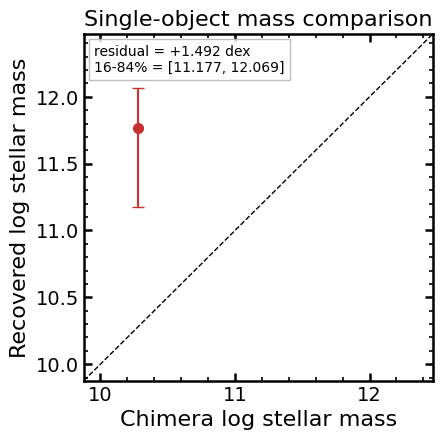

In [5]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.errorbar(
    [truth_logm],
    [recovered_logm],
    yerr=[[recovered_logm - logm16], [logm84 - recovered_logm]],
    fmt="o",
    color="#c53030",
    capsize=4,
    ms=7,
)
lims = [min(truth_logm, logm16) - 0.4, max(truth_logm, logm84) + 0.4]
ax.plot(lims, lims, color="black", ls="--", lw=1.0)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Chimera log stellar mass")
ax.set_ylabel("Recovered log stellar mass")
ax.set_title("Single-object mass comparison")
ax.text(
    0.03,
    0.97,
    f"residual = {recovered_logm - truth_logm:+.3f} dex\n16-84% = [{logm16:.3f}, {logm84:.3f}]",
    transform=ax.transAxes,
    va="top",
    ha="left",
    fontsize=10,
    bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.7"},
)
plt.show()


## Generate a component SED plot

`fit()` defers predictive model evaluation until you explicitly request it. Calling `plot_sed()` will trigger the predictive path and draw the total model, the stellar host, the host dust IR re-emission, and the AGN sub-components together with the observed photometry. Zero-only AGN branches are omitted from the plot automatically, so Sy2/LINER fits stay uncluttered.


/Users/colinburke/research/grahspj/src/grahspj/plotting.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


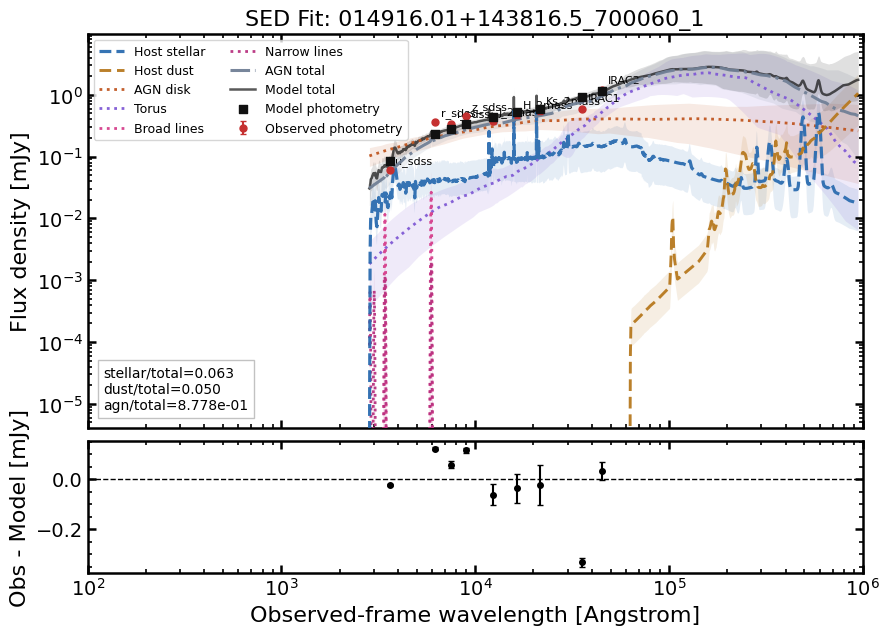

filter, eff_wave_A, obs_mJy, model_mJy, host_stellar_mJy, host_dust_mJy, agn_mJy
('u_sdss', np.float64(3614.373573958611), 0.06089159846305847, np.float64(0.0716440357799749), np.float64(0.04167371872593449), np.float64(0.0), np.float64(0.0299703170540404))
('r_sdss', np.float64(6205.832237243061), 0.35920968651771545, np.float64(0.23799419223301826), np.float64(0.06575587303094811), np.float64(0.0), np.float64(0.17223831920207017))
('i_sdss', np.float64(7525.622462977008), 0.3431943655014038, np.float64(0.29355619872486044), np.float64(0.06773970766870577), np.float64(0.0), np.float64(0.22581649105615462))
('z_sdss', np.float64(8947.384740828762), 0.45071807503700256, np.float64(0.3440508397781085), np.float64(0.07176970017487254), np.float64(0.0), np.float64(0.2722811396032359))
('J_2mass', np.float64(12407.991602068245), 0.3758549094200134, np.float64(0.4825730750120413), np.float64(0.13346995573448514), np.float64(0.0), np.float64(0.3491031192775561))
('H_2mass', np.float64(16513.6

[('u_sdss',
  np.float64(3614.373573958611),
  0.06089159846305847,
  np.float64(0.0716440357799749),
  np.float64(0.04167371872593449),
  np.float64(0.0),
  np.float64(0.0299703170540404)),
 ('r_sdss',
  np.float64(6205.832237243061),
  0.35920968651771545,
  np.float64(0.23799419223301826),
  np.float64(0.06575587303094811),
  np.float64(0.0),
  np.float64(0.17223831920207017)),
 ('i_sdss',
  np.float64(7525.622462977008),
  0.3431943655014038,
  np.float64(0.29355619872486044),
  np.float64(0.06773970766870577),
  np.float64(0.0),
  np.float64(0.22581649105615462))]

In [6]:
pred = fitter.predict()
fig = fitter.plot_sed(show=True)

model_flux = np.asarray(pred["pred_fluxes"][0], dtype=float)
host_flux = np.asarray(pred["host_fluxes"][0], dtype=float)
dust_flux = np.asarray(pred["dust_fluxes"][0], dtype=float)
agn_flux = np.asarray(pred["agn_fluxes"][0], dtype=float)
phot_wave = np.asarray([flt.effective_wavelength for flt in fitter.context.filters], dtype=float)
dust_luminosity = float(np.median(np.asarray(pred["dust_luminosity"], dtype=float)))

component_table = [
    (name, wave, obs, model, host, dust, agn)
    for name, wave, obs, model, host, dust, agn in zip(
        cfg.photometry.filter_names,
        phot_wave,
        cfg.photometry.fluxes,
        model_flux,
        host_flux,
        dust_flux,
        agn_flux,
    )
]
print("filter, eff_wave_A, obs_mJy, model_mJy, host_stellar_mJy, host_dust_mJy, agn_mJy")
for row_vals in component_table:
    print(row_vals)

print("dust luminosity [W]:", dust_luminosity)
print("stellar / total model:", float(np.sum(host_flux) / np.maximum(np.sum(model_flux), 1e-30)))
print("dust / total model:", float(np.sum(dust_flux) / np.maximum(np.sum(model_flux), 1e-30)))
print("agn / total model:", float(np.sum(agn_flux) / np.maximum(np.sum(model_flux), 1e-30)))

component_table[:3]


In [ ]:
import corner

samples = fitter.samples

preferred_params = [
    "log_stellar_mass",
    "log_agn_amp",
    "ebv_gal",
    "ebv_agn",
    "dust_alpha",
    "intrinsic_scatter_fit",
]
param_names = [p for p in preferred_params if p in samples]

if len(param_names) < 2:
    # fallback: pick first numeric sample arrays
    param_names = []
    for k, v in samples.items():
        arr = np.asarray(v)
        if arr.size > 0 and np.issubdtype(arr.dtype, np.number):
            param_names.append(k)
        if len(param_names) >= 6:
            break

X = np.column_stack([np.asarray(samples[p], dtype=float).reshape(-1) for p in param_names])

truths = [truth_logm if p == "log_stellar_mass" else None for p in param_names]

fig = corner.corner(
    X,
    labels=param_names,
    truths=truths,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt=".3f",
    bins=30,
)

fig.suptitle(f"Posterior corner plot (object_id={row['id']})", y=1.02)
plt.show()

## Next steps

- compare the printed host and AGN model photometry against the observed points band by band
- if the model is still too host-dominated, tighten `cfg.prior_config["log_stellar_mass"]` and/or broaden `cfg.prior_config["log_agn_amp"]`
- increase `cfg.inference.map_steps`, `num_warmup`, and `num_samples` for a stronger posterior fit
- use `fitter.save(...)` to write a posterior bundle
- swap in your own photometry by constructing a custom `FitConfig`